In [3]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI

import os
import sys

# Change to the desired directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

# Add it to Python path
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike
import modeselector
import parismc
# import gc
# import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")


# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 0.25     # Total time

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": "cuda12x" # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
    "pad_output": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs,
    use_gpu=use_gpu
)

print('Done initializing waveform generator.')

#Generating data (true)

# Source parameters
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 7.5
e0 = 0.4 
xI0 = 1.0 #NOTE: fixed
dist = 0.5 # Gpc
# Polar and azimuthal angles .. detector frame
# S = Solar system barycenter
# K = spin angular momentum of the MBH
qS = 0.5 
phiS = 1 
qK = 1 #NOTE: fixed
phiK = phiS + np.pi/3
# Phases
Phi_phi0 = 0.4
Phi_theta0 = 0.0 # NOTE: fixed
Phi_r0 = 0.5

print('Generating data signal...')
data = waveform_gen(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt)
print('Done generating data signal.')
param_true_ori = [m1, m2, a, p0, e0, dist, qS, Phi_phi0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0, dist, np.cos(qS), Phi_phi0, Phi_r0]


print('Setting up GWFuncs...')
gwf = GWfuncs.GravWaveAnalysis(T, dt)
print('Done setting up GWFuncs.')

print('Calculating SNR...')
data_f = gwf.freq_wave(data)
data_snr = gwf.SNR(data_f)
print('SNR calculated:', data_snr)

print('Setting up log-likelihood and prior...')
def loglike(params):

    params = np.asarray(params)

    n_samples = params.shape[0]
    log_likes = np.zeros(n_samples)

    for i in range(n_samples):
        logm1, logm2, a, p0, e0, dist, cosqS, Phi_phi0, Phi_r0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2
        qS = np.arccos(cosqS)
        # phiK = phiS + np.pi/3

        htemp = waveform_gen(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
                            Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt)
        

        res = data - htemp
        res_f = gwf.freq_wave(res)
        inner_res = gwf.inner(res_f, res_f)
        log_likes[i] = -0.5 * inner_res

    return log_likes

    
def prior_transform(u):


    # WIDER using diag of cov
    # 3 sigma
    # logm1lim = [5.999755966003094, 6.000244033996906]
    # logm2lim = [1.4769870513061485, 1.4772554581331763]
    # alim = [0.6995637359288023, 0.7004362640711976]
    # p0lim = [7.497572969128289, 7.502427030871711]
    # e0lim = [0.39989407441630453, 0.4001059255836955]
    # distlim = [0.4671238045922167, 0.5328761954077833]
    # cosqSlim = [0.8175373164938913, 0.9376278072868542]
    # phiSlim = [0.8907980491383655, 1.1092019508616344]
    # Phiphilim = [0.2971011746225549, 0.5028988253774451]
    # Phirlim = [0.4374942669461721, 0.5625057330538279]

    del_int = [100, 1e-3, 1e-4, 1e-4, 1e-4]  # m1, m2, a, p0, e0
    del_D = param_true[5]/np.sqrt(data_snr)

    # chain rule
    del_logm1 = del_int[0]/(param_true_ori[0]*np.log(10))
    del_logm2 = del_int[1]/(param_true_ori[1]*np.log(10))

    n = 10
    # from readme.md - convert to float to avoid CuPy/NumPy type mixing
    logm1lim = [float(param_true[0] - n*del_logm1), float(param_true[0] + n*del_logm1)]
    logm2lim = [float(param_true[1] - n*del_logm2), float(param_true[1] + n*del_logm2)]
    alim = [float(param_true[2] - n*del_int[2]), 0.999]
    p0lim = [float(param_true[3] - n*del_int[3]), float(param_true[3] + n*del_int[3])]
    e0lim = [float(param_true[4] - n*del_int[4]), float(param_true[4] + n*del_int[4])]
    distlim = [float(param_true[5] - n*del_D), float(param_true[5] + n*del_D)]
    cosqSlim = [-1.0, 1.0] # in readme: qS = (0, pi)
    # phiSlim = [0.0, 2*np.pi]
    Phiphilim = [0.0, 2*np.pi]
    Phirlim = [0.0, 2*np.pi]

 

    transformed = np.zeros_like(u)

    # Uniform in log for masses

    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]

    # Uniform for other parameters

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    # dist 
    transformed[:, 5] = (distlim[1] - distlim[0]) * u[:, 5] + distlim[0]

    # qS
    transformed[:, 6] = (cosqSlim[1] - cosqSlim[0]) * u[:, 6] + cosqSlim[0]

    # phiS
    # transformed[:, 7] = (phiSlim[1] - phiSlim[0]) * u[:, 7] + phiSlim[0]

    # Phi_phi0
    transformed[:, 7] = (Phiphilim[1] - Phiphilim[0]) * u[:, 7] + Phiphilim[0]

    # Phi_r0
    transformed[:, 8] = (Phirlim[1] - Phirlim[0]) * u[:, 8] + Phirlim[0]

    
    return transformed
print('Done setting up log-likelihood and prior.')


Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Generating data signal...
Done generating data signal.
Setting up GWFuncs...
Done setting up GWFuncs.
Calculating SNR...
SNR calculated: 107.43944631400305
Setting up log-likelihood and prior...
Done setting up log-likelihood and prior.


In [4]:
# Change to the desired directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/sampling_test')

# Add it to Python path
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/sampling_test')

sampler = parismc.Sampler.load_state('./paris_likelihoodtest_ref/sampler_state.pkl')
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [5]:
sampler.prior_transform(np.array([[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]]))


array([[ 5.99956571,  1.47697649,  0.699     ,  7.499     ,  0.399     ,
         0.0176213 , -1.        ,  0.        ,  0.        ,  0.        ]])

In [6]:
sampler.prior_transform(np.array([[1.,1.,1.,1.,1.,1.,1.,1.,1.,1.]]))

array([[6.00043429, 1.47726602, 0.999     , 7.501     , 0.401     ,
        0.9823787 , 1.        , 6.28318531, 6.28318531, 0.        ]])

In [10]:
del_int = [100, 1e-3, 1e-4, 1e-4, 1e-4]  # m1, m2, a, p0, e0
del_D = param_true[5]/np.sqrt(data_snr)

# chain rule
del_logm1 = del_int[0]/(param_true_ori[0]*np.log(10))
del_logm2 = del_int[1]/(param_true_ori[1]*np.log(10))

n = 10

param_ranges = [
    (float(param_true[0] - n*del_logm1), float(param_true[0] + n*del_logm1)),  # logm1
    (float(param_true[1] - n*del_logm2), float(param_true[1] + n*del_logm2)),  # logm2
    (float(param_true[2] - n*del_int[2]), 0.999),  # a
    (float(param_true[3] - n*del_int[3]), float(param_true[3] + n*del_int[3])),  # p0
    (float(param_true[4] - n*del_int[4]), float(param_true[4] + n*del_int[4])),  # e0
    (float(param_true[5] - n*del_D), float(param_true[5] + n*del_D)),  # dist
    (-1.0, 1.0),  # cosqS
    (0.0, 2*np.pi),  # Phiphi
    (0.0, 2*np.pi)  # Phir
]

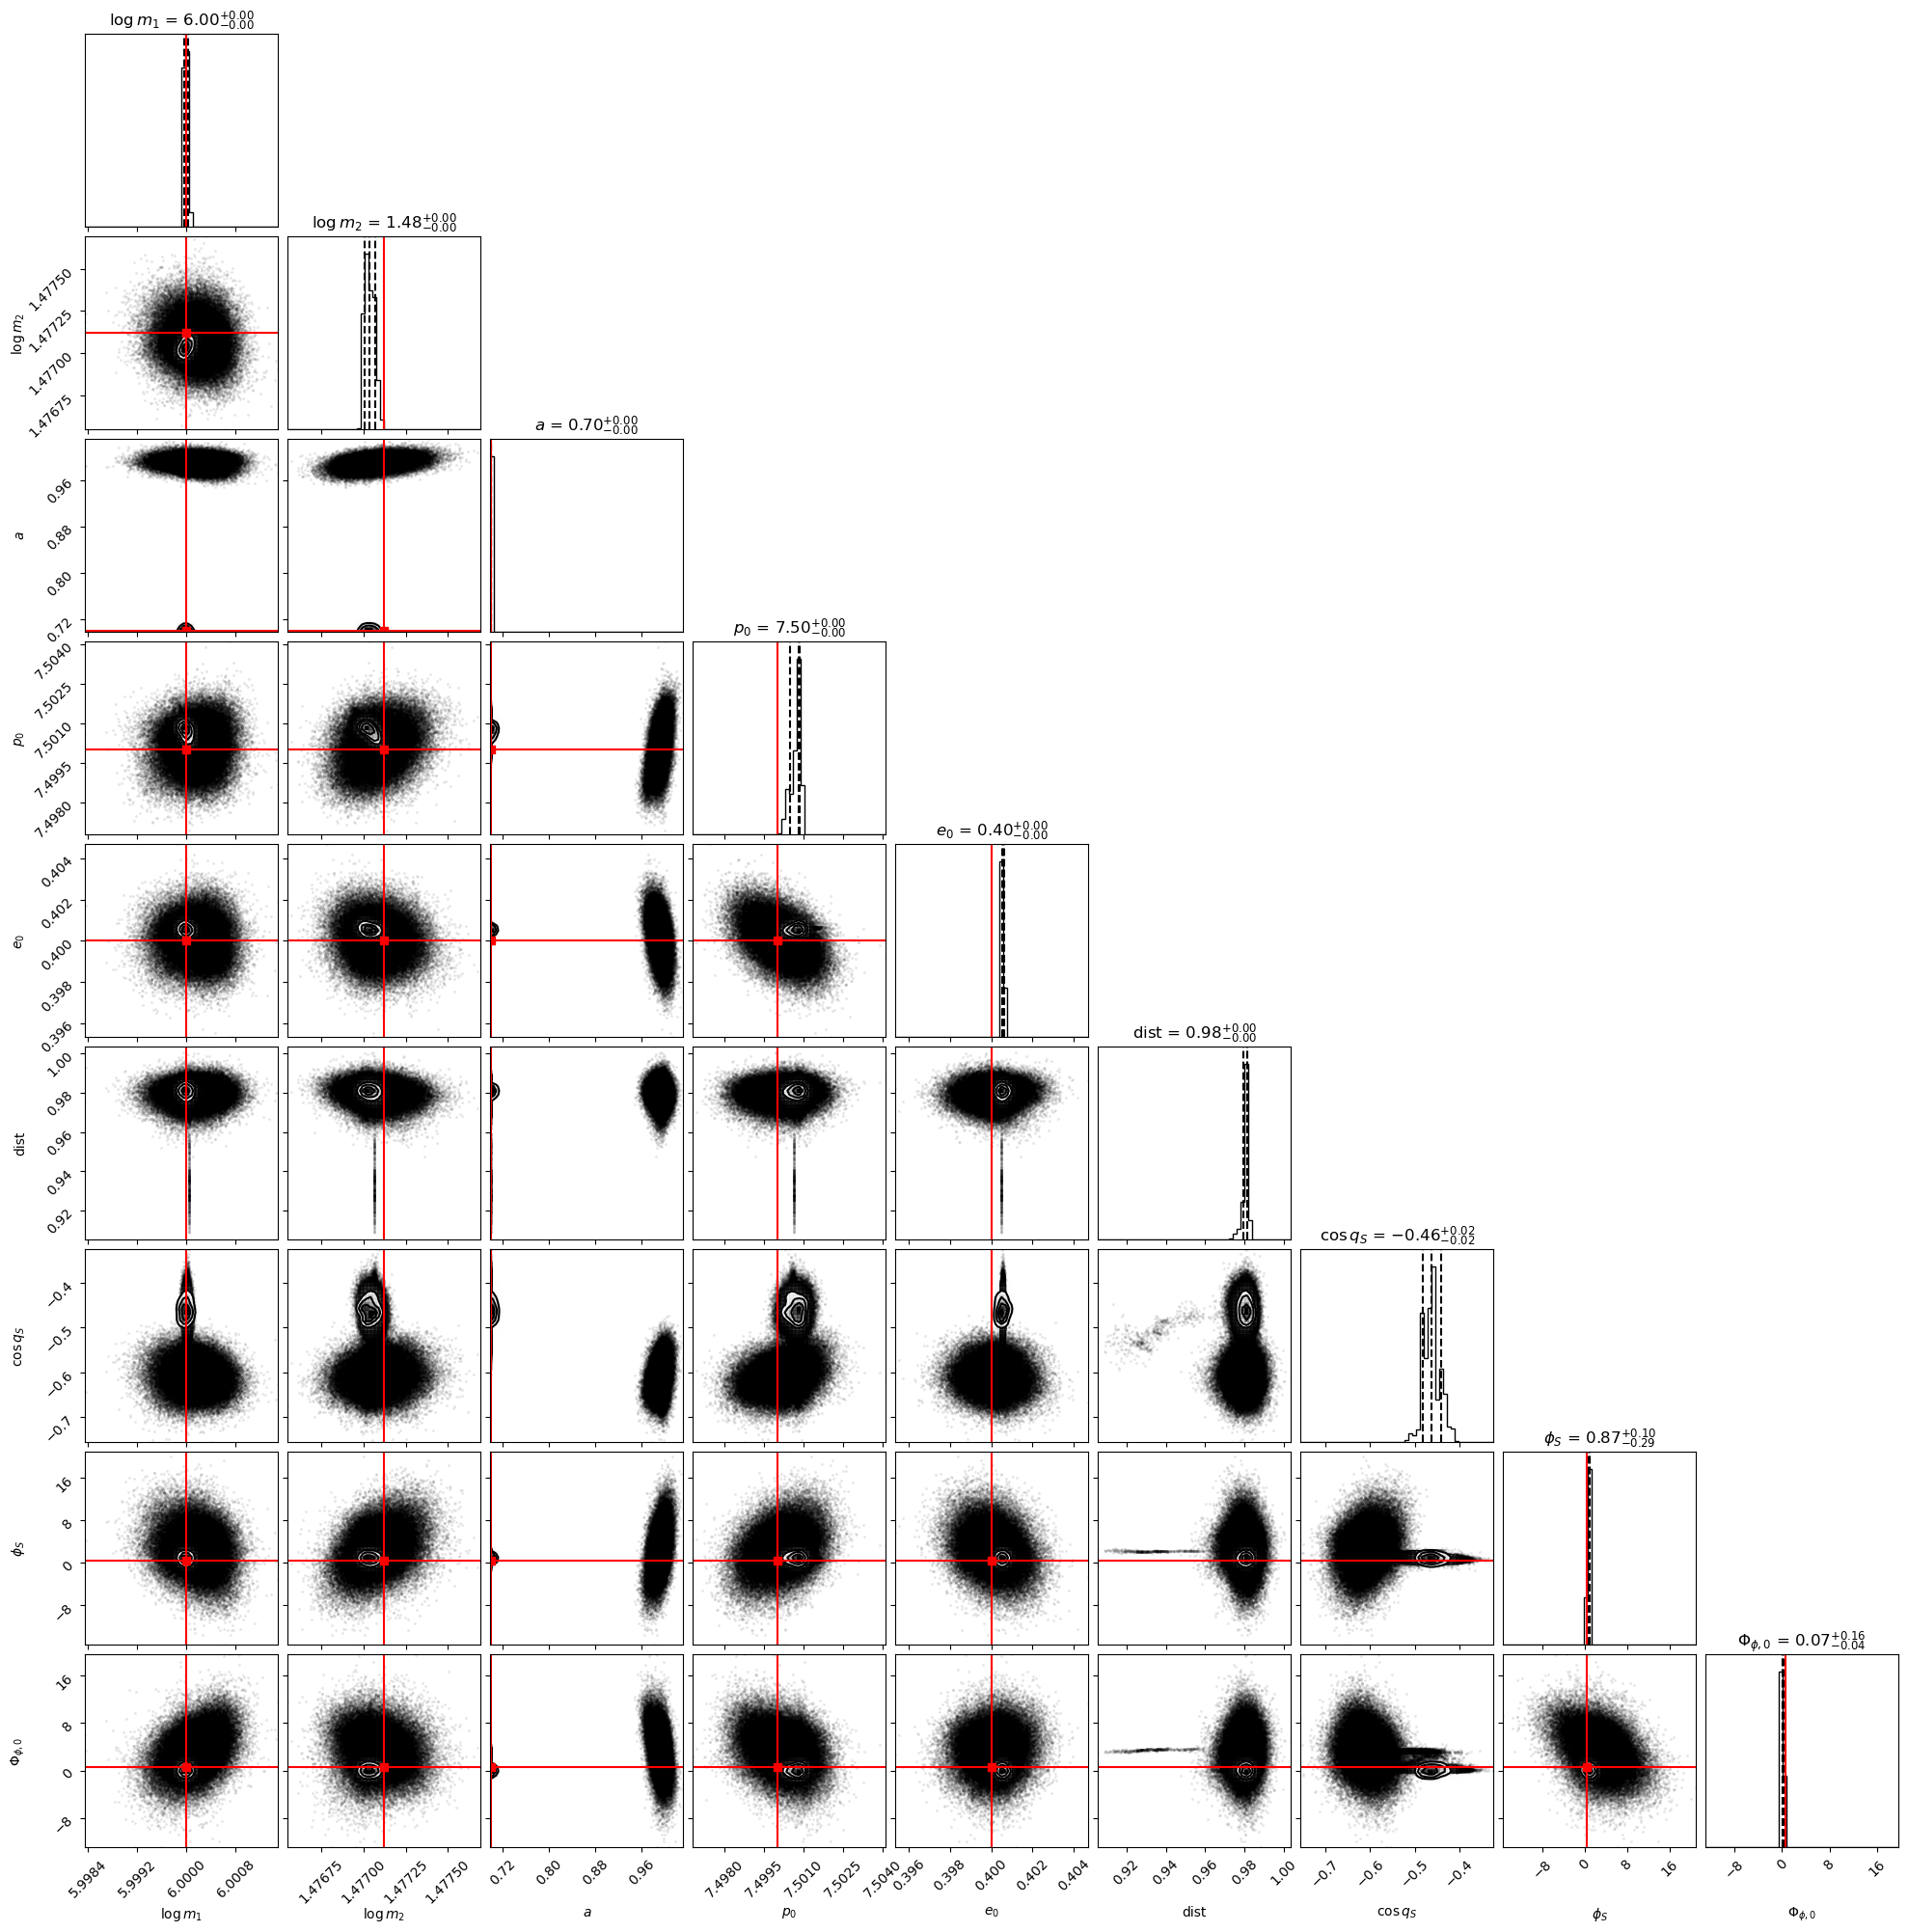

In [11]:

import corner
labels = [r'$\log{m_1}$', r'$\log{m_2}$',r'$a$',r'$p_0$',r'$e_0$',r'dist',r'$\cos{q_S}$', r'$\phi_S$',
        r'$\Phi_{\phi,0}$', r'$\Phi_{r,0}$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],  # 1-sigma and median
    smooth=True,
    bins=50,
    ranges = param_ranges,
)